In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
df.shape

(1460, 81)

In [4]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
print(df["SalePrice"].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


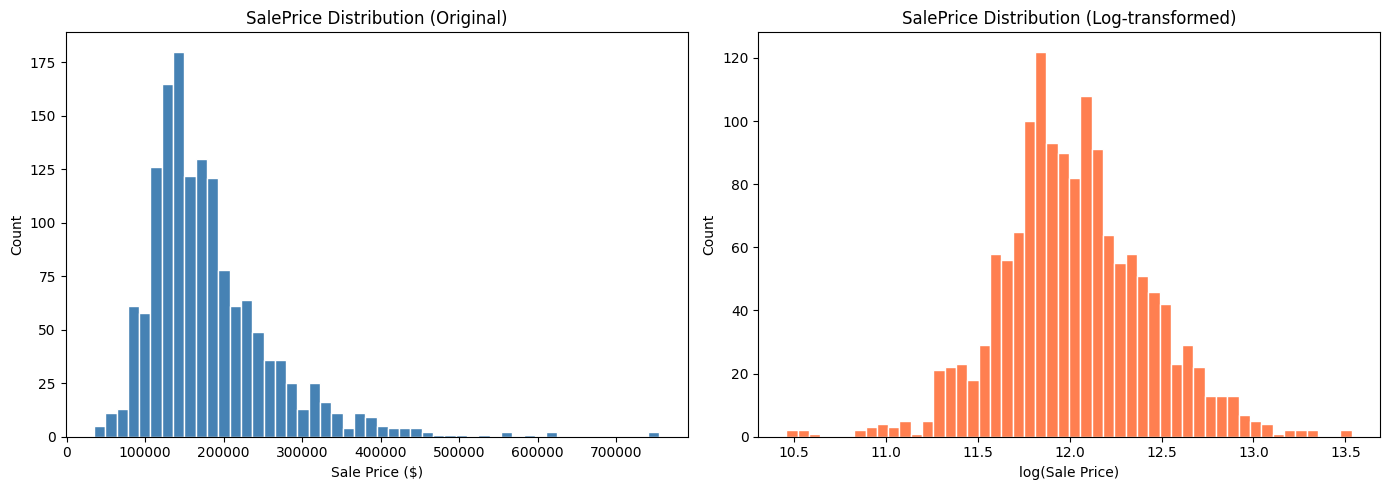

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Original)')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log-transformed)')
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

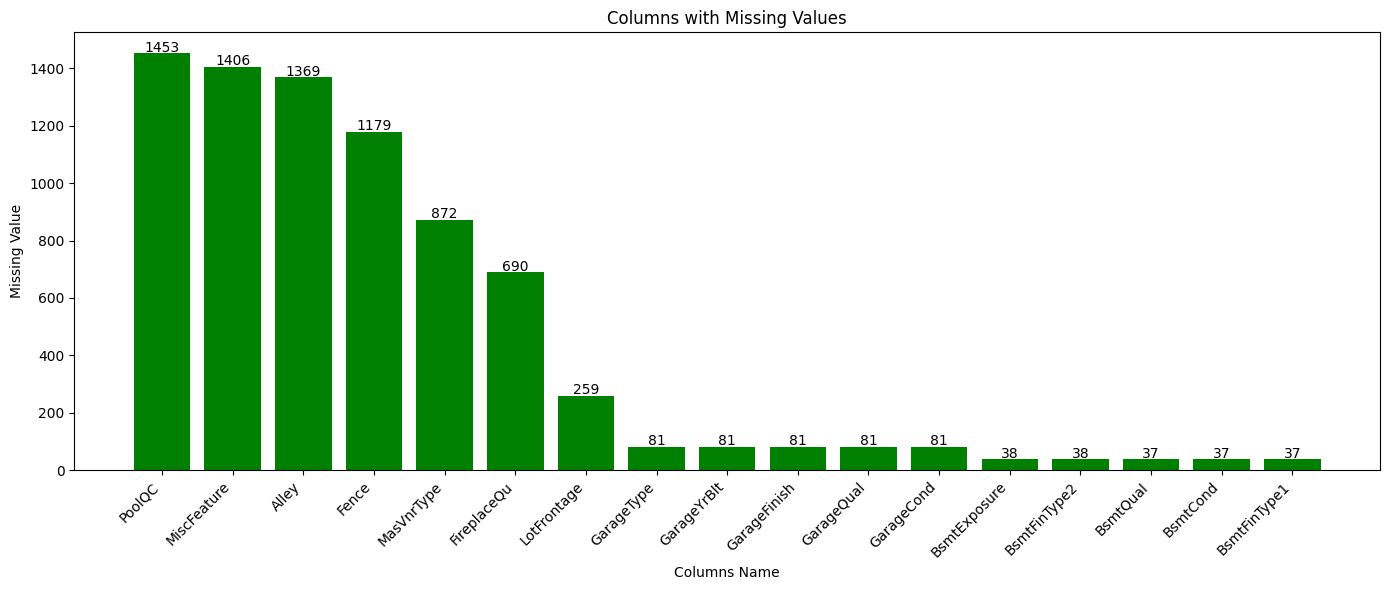

In [10]:
plt.figure(figsize=(14,6))
bars = plt.bar(missing.index[:17],missing.values[:17],color = "green")
plt.title("Columns with Missing Values")
plt.xlabel("Columns Name")
plt.ylabel("Missing Value")
plt.xticks(rotation = 45, ha ='right')
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 5,
        int(yval),
        ha = 'center'
        )

plt.tight_layout()
plt.show()

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
correlations

OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

In [12]:
top_corr = correlations.head(30)
colors = ['marron' if v > 0 else 'orange' for v in  top_corr.values]

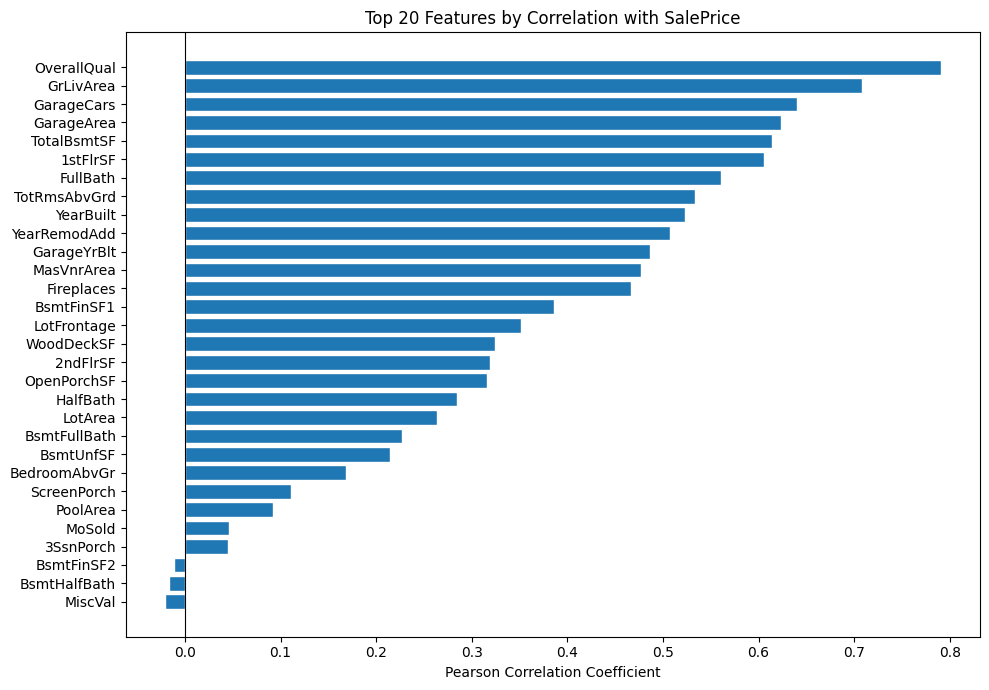

In [13]:
plt.figure(figsize=(10, 7))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features by Correlation with SalePrice')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

In [14]:
top_corr.head(30)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
LotArea         0.263843
BsmtFullBath    0.227122
BsmtUnfSF       0.214479
BedroomAbvGr    0.168213
ScreenPorch     0.111447
PoolArea        0.092404
MoSold          0.046432
3SsnPorch       0.044584
BsmtFinSF2     -0.011378
BsmtHalfBath   -0.016844
MiscVal        -0.021190
Name: SalePrice, dtype: float64

In [15]:
Num_features = [
    'BsmtFullBath',
    'BsmtUnfSF',
    'BedroomAbvGr',
    'ScreenPorch',
    'PoolArea',
    'MoSold',
    '3SsnPorch',
    'BsmtFinSF2',
    'BsmtHalfBath',
    'MiscVal',
    'BsmtFinSF1',
    'LotFrontage',
    'WoodDeckSF',
    '2ndFlrSF',
    'OpenPorchSF',
    'HalfBath',
    'LotArea',
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'TotRmsAbvGrd',
    'YearBuilt',
    'YearRemodAdd',
    'GarageYrBlt',
    'MasVnrArea',
    'Fireplaces'
]
Phy_features = [
    'Neighborhood', 
    'MSZoning',  
    'SaleCondition',
    'KitchenQual', 
    'ExterQual'
]
All_features = Num_features + Phy_features
All_features

['BsmtFullBath',
 'BsmtUnfSF',
 'BedroomAbvGr',
 'ScreenPorch',
 'PoolArea',
 'MoSold',
 '3SsnPorch',
 'BsmtFinSF2',
 'BsmtHalfBath',
 'MiscVal',
 'BsmtFinSF1',
 'LotFrontage',
 'WoodDeckSF',
 '2ndFlrSF',
 'OpenPorchSF',
 'HalfBath',
 'LotArea',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath',
 'TotRmsAbvGrd',
 'YearBuilt',
 'YearRemodAdd',
 'GarageYrBlt',
 'MasVnrArea',
 'Fireplaces',
 'Neighborhood',
 'MSZoning',
 'SaleCondition',
 'KitchenQual',
 'ExterQual']

In [16]:
X = df[All_features].copy()
y = df['SalePrice']

In [17]:
for col in Num_features:
    median_val = X[col].median()
    missing_count = X[col].isnull().sum()
    if missing_count > 0:
        print(f'  {col}: filled {missing_count} missing values with median={median_val:.1f}')
    X[col] = X[col].fillna(median_val)

  LotFrontage: filled 259 missing values with median=69.0
  GarageYrBlt: filled 81 missing values with median=1980.0
  MasVnrArea: filled 8 missing values with median=0.0


In [18]:
le = LabelEncoder()
for col in Phy_features:
    X[col] = X[col].fillna('Unknown')
    X[col] = le.fit_transform(X[col])
    print(f'  {col}: encoded into {X[col].nunique()} categories')

  Neighborhood: encoded into 25 categories
  MSZoning: encoded into 5 categories
  SaleCondition: encoded into 6 categories
  KitchenQual: encoded into 4 categories
  ExterQual: encoded into 4 categories


In [19]:
print(f'\nFinal feature matrix shape: {X.shape}')
print('Missing values remaining:', X.isnull().sum().sum())


Final feature matrix shape: (1460, 35)
Missing values remaining: 0


In [20]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
X_train

,BsmtFullBath,BsmtUnfSF,BedroomAbvGr,ScreenPorch,PoolArea,MoSold,3SsnPorch,BsmtFinSF2,BsmtHalfBath,MiscVal,...,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,Neighborhood,MSZoning,SaleCondition,KitchenQual,ExterQual
254,1,392,3,0,0,6,0,0,0,0,...,1957,1957,1957.0,0.0,0,12,3,4,3,3
1066,0,799,3,0,0,5,0,0,0,0,...,1993,1994,1993.0,0.0,1,8,3,4,3,2
638,0,796,2,0,0,5,0,0,0,0,...,1910,1950,1980.0,0.0,0,7,3,4,3,3
799,1,162,3,0,0,6,0,0,0,0,...,1937,1950,1939.0,252.0,2,18,3,4,2,3
380,0,808,3,0,0,5,0,0,0,0,...,1924,1950,1924.0,0.0,1,18,3,4,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,0,1290,3,0,0,3,0,0,0,0,...,2006,2006,2006.0,0.0,1,5,3,4,2,2
1130,1,500,4,0,0,12,0,0,0,0,...,1928,1950,1981.0,0.0,2,18,3,4,2,3
1294,1,697,2,0,0,4,0,0,0,0,...,1955,1990,1957.0,0.0,0,7,3,4,3,3
860,0,912,3,0,0,6,0,0,0,0,...,1918,1998,1925.0,0.0,1,6,3,4,2,2


In [22]:
X_test

,BsmtFullBath,BsmtUnfSF,BedroomAbvGr,ScreenPorch,PoolArea,MoSold,3SsnPorch,BsmtFinSF2,BsmtHalfBath,MiscVal,...,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,Neighborhood,MSZoning,SaleCondition,KitchenQual,ExterQual
892,0,396,3,0,0,2,0,0,1,0,...,1963,2003,1963.0,0.0,0,19,3,4,3,3
1105,1,431,3,0,0,4,0,0,0,0,...,1994,1995,1994.0,362.0,2,15,3,4,2,2
413,0,1008,2,0,0,3,0,0,0,0,...,1927,1950,1927.0,0.0,1,17,4,4,3,3
522,0,605,3,0,0,10,0,0,0,0,...,1947,1950,1950.0,0.0,2,3,4,4,3,3
1036,1,598,2,0,0,9,0,0,0,0,...,2007,2008,2008.0,70.0,1,23,3,4,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,0,739,2,0,0,3,0,0,0,0,...,1937,2000,1995.0,435.0,0,17,4,2,3,3
1361,1,256,3,0,0,6,0,0,0,0,...,2005,2005,2005.0,16.0,1,22,3,4,2,2
802,1,80,3,0,0,10,0,0,0,0,...,2005,2005,2005.0,0.0,1,5,3,4,2,2
651,1,755,4,0,0,10,0,0,0,0,...,1940,1950,1940.0,0.0,1,7,3,4,3,3


In [23]:
y_train

254     145000
1066    178000
638      85000
799     175000
380     127000
         ...  
1095    176432
1130    135000
1294    115000
860     189950
1126    174000
Name: SalePrice, Length: 1168, dtype: int64

In [24]:
y_test

892     154500
1105    325000
413     115000
522     159000
1036    315500
         ...  
479      89471
1361    260000
802     189000
651     108000
722     124500
Name: SalePrice, Length: 292, dtype: int64

In [25]:
scaler = StandardScaler()

In [26]:
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [27]:
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 1168 samples
Test set:     292 samples


In [28]:
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
y_pred_test = lr_model.predict(X_test_sc)
y_pred_train = lr_model.predict(X_train_sc)
print('Linear Regression R²:', round(r2_score(y_test, y_pred_test), 4))

Linear Regression R²: 0.8339


In [29]:
r2   = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)
print(r2)
print(rmse)
print(mae)

0.8339366532536086
35689.77501473005
22326.792462389567


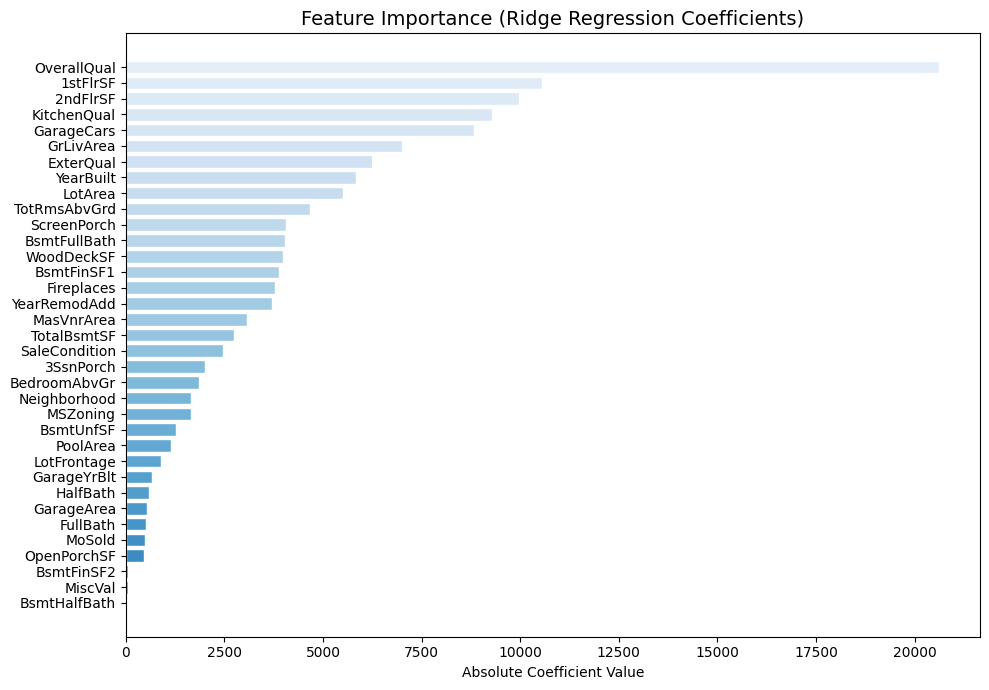


Top 10 most important features:
OverallQual     20627.164423
1stFlrSF        10545.958163
2ndFlrSF         9974.060176
KitchenQual      9296.958785
GarageCars       8821.113218
GrLivArea        6994.920216
ExterQual        6239.812197
YearBuilt        5826.354244
LotArea          5496.842013
TotRmsAbvGrd     4658.389936


In [30]:
# Ridge model coefficients (absolute value = importance)
importance = pd.Series(
    np.abs(lr_model.coef_),
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(importance)))
bars = plt.barh(importance.index[::-1], importance.values[::-1],
                color=colors, edgecolor='white')
plt.title('Feature Importance (Ridge Regression Coefficients)', fontsize=14)
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
print(importance.head(10).to_string())

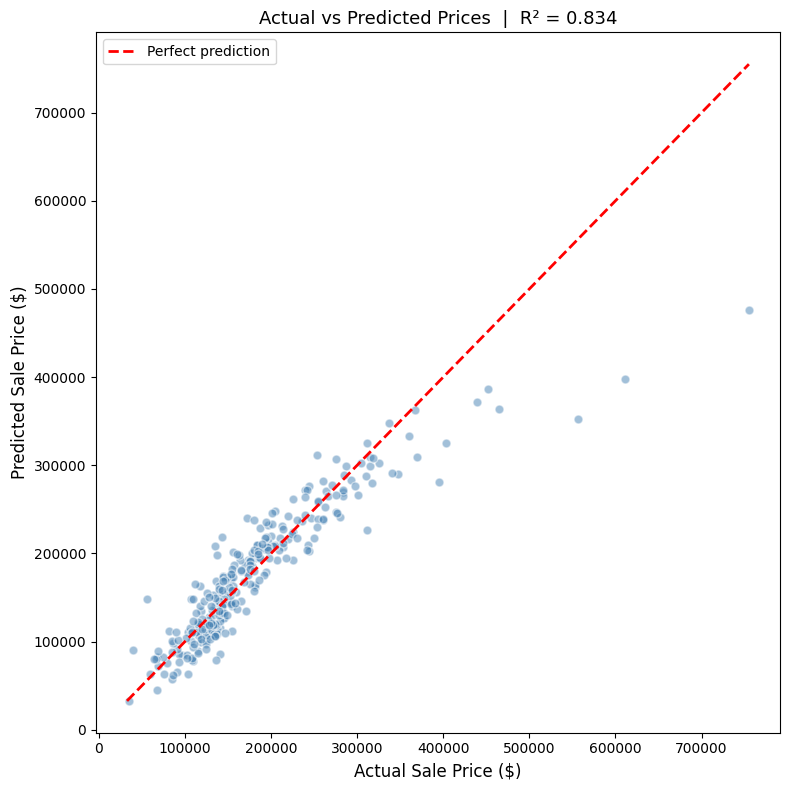

In [31]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='steelblue', edgecolors='white', s=40)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.title(f'Actual vs Predicted Prices  |  R² = {r2:.3f}', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

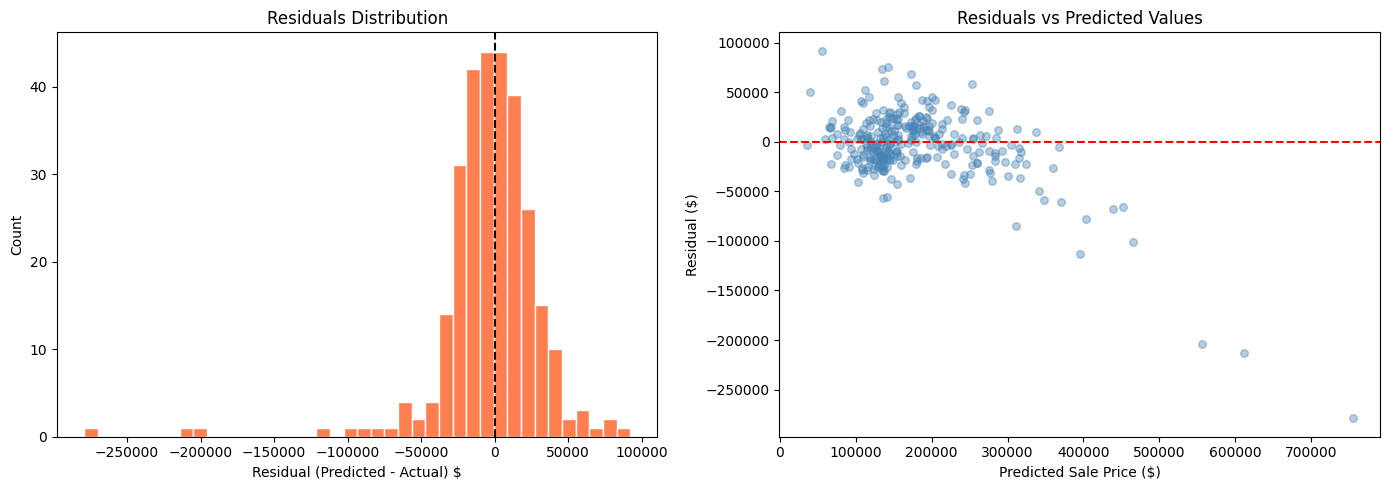

In [32]:
# Plot 2: Residuals distribution
residuals = y_pred_test - y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual histogram
axes[0].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals Distribution')
axes[0].set_xlabel('Residual (Predicted - Actual) $')
axes[0].set_ylabel('Count')

# Residuals vs Predicted
axes[1].scatter(y_test, residuals, alpha=0.4, color='steelblue', s=30)
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Residuals vs Predicted Values')
axes[1].set_xlabel('Predicted Sale Price ($)')
axes[1].set_ylabel('Residual ($)')

plt.tight_layout()
plt.show()

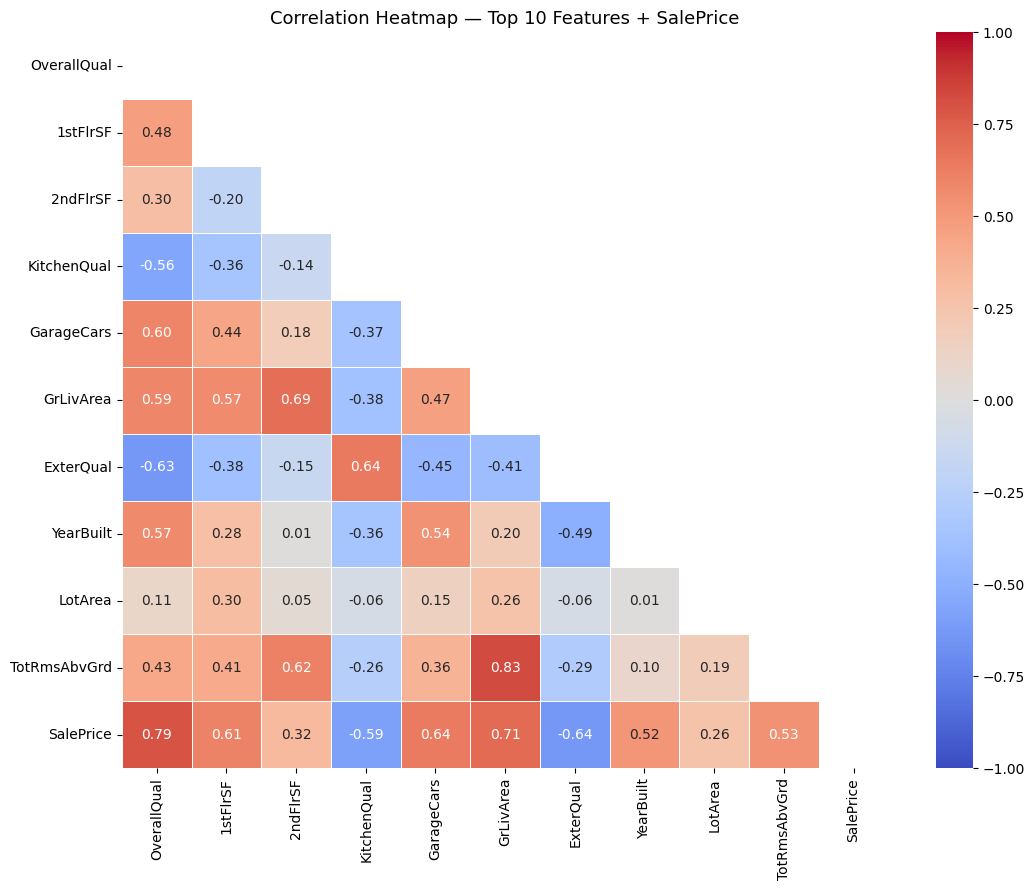

In [33]:
# Plot 3: Correlation heatmap (top features only)
top_features = importance.head(10).index.tolist() + ['SalePrice']
heat_df = df[top_features].copy()

# Encode any remaining categoricals
for col in heat_df.select_dtypes(include='object').columns:
    heat_df[col] = LabelEncoder().fit_transform(heat_df[col].fillna('Unknown'))

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(heat_df.corr(), dtype=bool))
sns.heatmap(heat_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Top 10 Features + SalePrice', fontsize=13)
plt.tight_layout()
plt.show()

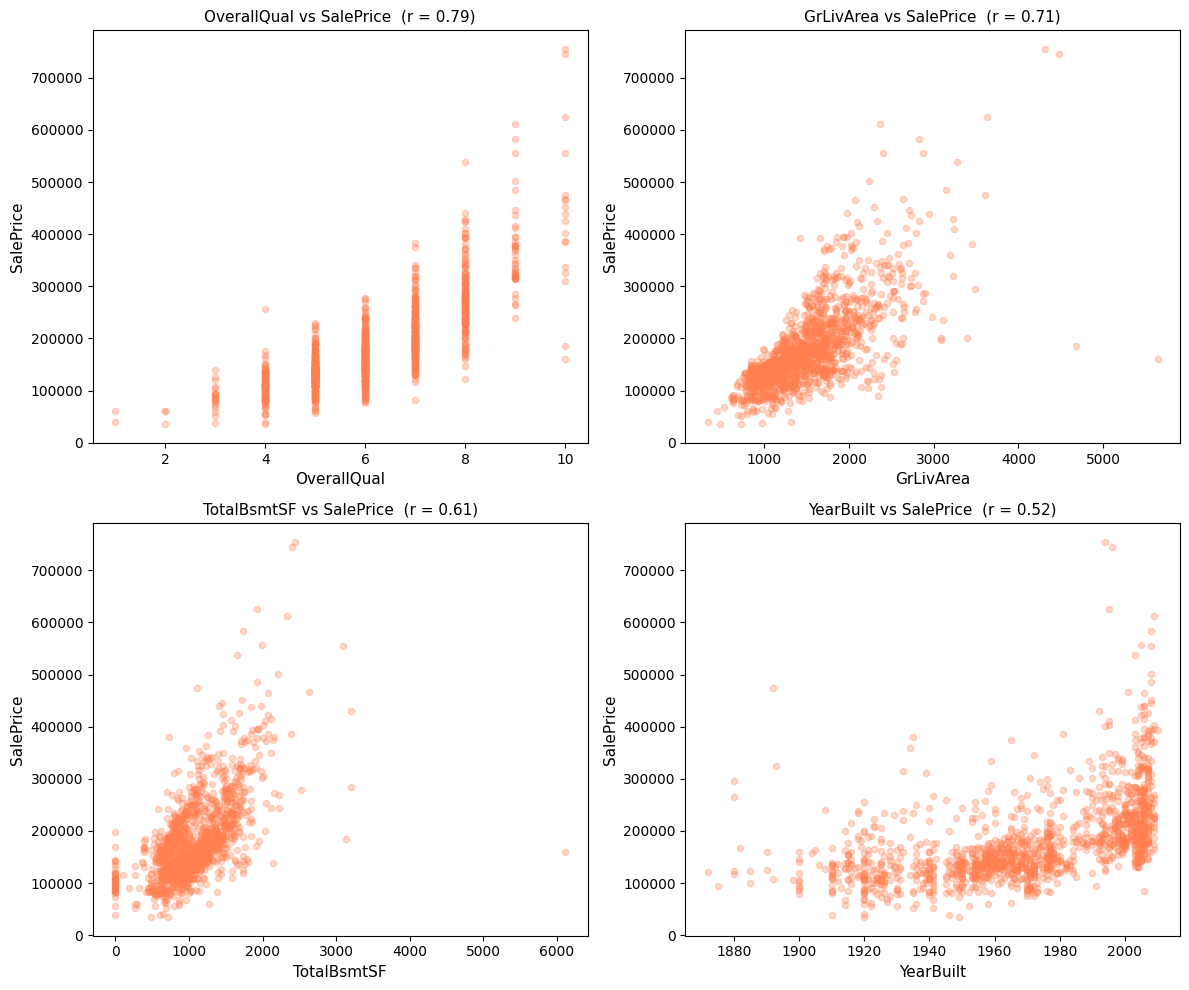

In [34]:
# Plot 4: Top 4 features vs SalePrice scatter
top4 = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feat in enumerate(top4):
    axes[i].scatter(df[feat], df['SalePrice'], alpha=0.3, color='coral', s=20)
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('SalePrice', fontsize=11)
    corr_val = df[[feat, 'SalePrice']].corr().iloc[0, 1]
    axes[i].set_title(f'{feat} vs SalePrice  (r = {corr_val:.2f})', fontsize=11)

plt.tight_layout()
plt.show()

In [38]:
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

In [39]:
model_columns = X.columns
with open("model_columns.pkl", "wb") as file:
    pickle.dump(model_columns, file)